# Análisis Tienda Online                                       

In [85]:
# vamos a cargar las librerias 
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import datetime as dt
from scipy import stats

In [86]:
# Vamos a cargar los datos del dataset df_hypotheses para la primera parte del análisis.
df_hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep= ';')

## Primera parte del proyecto 

Vamos a trabajar con el dataset df_hypotheses para priorizar hipótesis y analizar en detalle el framework RICE. 

In [87]:
# Revisión del tipo de datos del data set df_hypotheses
df_hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [88]:
df_hypotheses.columns = df_hypotheses.columns.str.lower()

In [89]:
# verificación explícita de duplicados
print("=== VERIFICACIÓN DE DUPLICADOS===")
print(f"Duplicados en df_hypotheses: {df_hypotheses.duplicated().sum()}")
print("\n=== DUPLICADOS POR COLUMNAS CLAVE===")
print(f"Hipotesis de como aumentar los ingresos de la tienda:{df_hypotheses.duplicated(['hypothesis','reach','impact','confidence','effort']).sum()}")

=== VERIFICACIÓN DE DUPLICADOS===
Duplicados en df_hypotheses: 0

=== DUPLICADOS POR COLUMNAS CLAVE===
Hipotesis de como aumentar los ingresos de la tienda:0


In [90]:
# Estudiaremos las hipótesis y los parámetros evaluados de ICE en el archivo. 
df_hypotheses['ICE'] = (df_hypotheses['impact']*df_hypotheses['confidence'])/df_hypotheses['effort']

In [91]:
# Se va a calcular el RICE para las hipótesis.
df_hypotheses['RICE'] = (df_hypotheses['reach']*df_hypotheses['impact']*df_hypotheses['confidence'])/df_hypotheses['effort']

In [92]:
# para compara las dos métricas hacer una versión más corta del dataset  
print("Priorización de RICE")
display(df_hypotheses[['hypothesis','RICE']].sort_values(by='RICE', ascending= False))
print("Priorización de ICE")
df_hypotheses[['hypothesis', 'ICE']].sort_values(by='ICE',ascending= False)

Priorización de RICE


,hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


Priorización de ICE


,hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


**-** Las hipótesis más prometedoras para Rice son:
- Agregar un formulario de suscripción en todas las páginas principales.
- Incorporar bloques de recomendación de productos en la tienda.
- Añadir dos nuevos canales para atraer tráfico.

**-** El ICE también presenta como hipótesis más prometedoras:
- Lanzar una promoción que ofrezca descuentos a los usuarios.
- Añadir dos nuevos canales para atraer tráfico.
- Agregar un formulario de suscripción en todas las páginas principales.

## Parte 2. Análisis del test A/B

In [93]:
# Vamos a cargar los datos del dataset df_orders y df_visists
df_orders = pd.read_csv('/datasets/orders_us.csv',
                        sep = ',',
                        parse_dates = ['date'])
                        # date_parser = lambda x:pd.to_datetime(x,format='%Y-%m-%d'))
df_visits = pd.read_csv('/datasets/visits_us.csv',
                        sep = ',',
                        parse_dates = ['date'])
                        #date_parser = lambda x:pd.to_datetime(x,format='%Y-%m-%d'))

In [94]:
df_orders.columns = df_orders.columns.str.lower()
df_visits.columns = df_visits.columns.str.lower()

### 1. Representación gráfica del ingreso acumulado por grupo.

In [95]:
datesgroups = df_orders[['date', 'group']].drop_duplicates()
ordersaggregate = datesgroups.apply(
    lambda x: df_orders[
        np.logical_and(
            df_orders['date'] <= x['date'], df_orders['group'] ==
x['group']
        )
    ].agg(
        {'date': 'max',
         'group': 'max',
         'transactionid': pd.Series.nunique,
         'visitorid': pd.Series.nunique,
         'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

visitorsaggregate = datesgroups.apply(
    lambda x: df_visits[
        np.logical_and(
            df_visits['date'] <= x['date'], df_visits['group'] ==
x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visits': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

cumulativedata = ordersaggregate.merge(
    visitorsaggregate, left_on=['date', 'group'],
right_on=['date', 'group']
)

cumulativedata.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

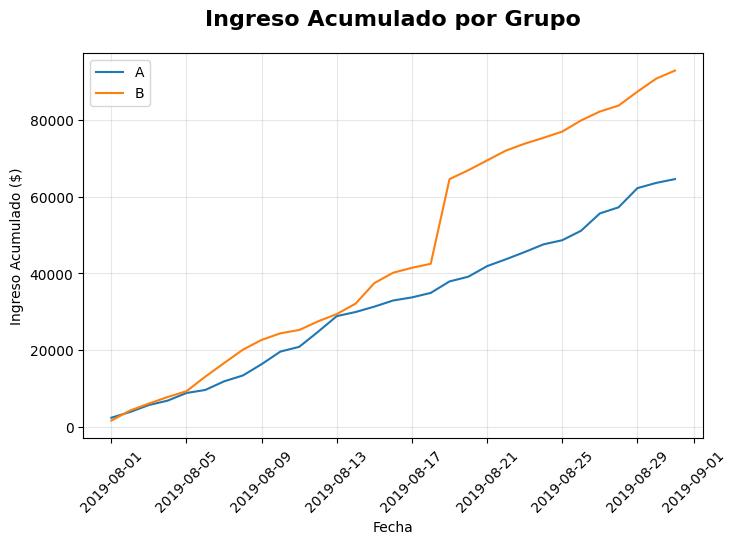

In [96]:
cumulativeRevenueA = cumulativedata[cumulativedata['group']
== 'A'][
    ['date', 'revenue', 'orders']
]
cumulativeRevenueB = cumulativedata[cumulativedata['group']
== 'B'][
    ['date', 'revenue', 'orders']
]
plt.figure(figsize=(8, 5)) 
plt.plot(cumulativeRevenueA['date'],cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'],cumulativeRevenueB['revenue'], label='B')
plt.legend()
plt.title('Ingreso Acumulado por Grupo', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha')
plt.ylabel('Ingreso Acumulado ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


**-** El segmento B tomó la delantera entre el 17 de agosto y el 21 de agosto del año 2019. 

### 2. Representación del tamaño promedio de pedido acumulado por grupo.

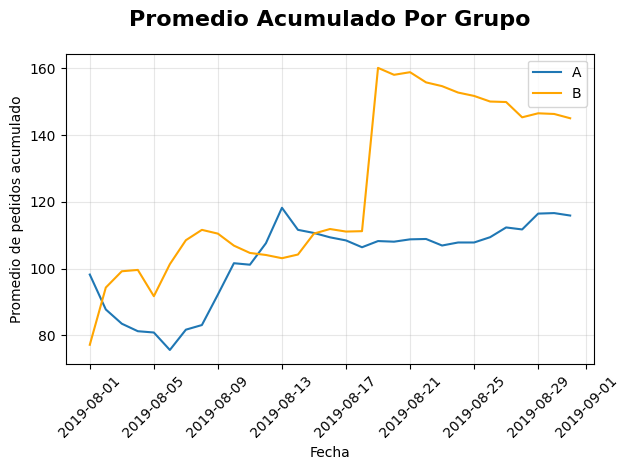

In [97]:
plt.plot(cumulativeRevenueA['date'],cumulativeRevenueA['revenue']/
cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/
cumulativeRevenueB['orders'], label='B', color='orange')
plt.title('Promedio Acumulado Por Grupo', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha')
plt.ylabel('Promedio de pedidos acumulado')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**-** El valor acumulado de los tamaños de compra promedio de los segmentos sigue fluctuando más en el grupo B, pero en los primeros días del mes de agosto de 1 al 17 sigue fluctuando en ambos grupos. Hay un cambio significativo a partir del 18 en el grupo B

### 3. Representación gráfica la diferencia relativa en el tamaño de pedido promedio de cada grupo A y B

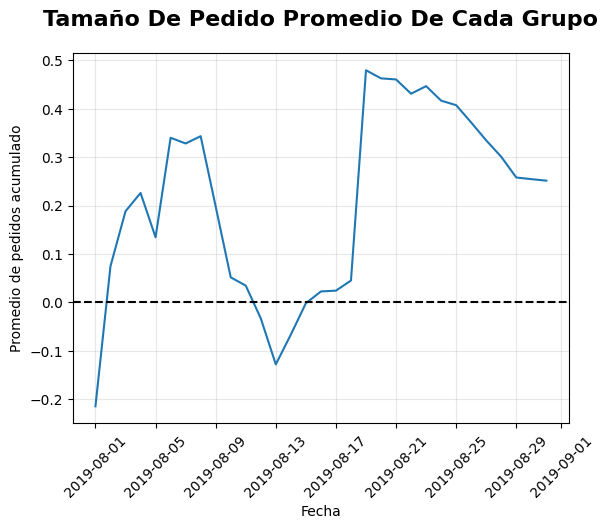

In [98]:
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB,
    left_on= 'date',
    right_on= 'date',
    how= 'left',
    suffixes= ['A','B']    
)
plt.plot(mergedCumulativeRevenue['date'],(mergedCumulativeRevenue['revenueB']/
mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/
mergedCumulativeRevenue['ordersA'])-1)
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.title('Tamaño De Pedido Promedio De Cada Grupo', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha')
plt.ylabel('Promedio de pedidos acumulado')
plt.grid(True, alpha=0.3)
plt.show()

**-** Podemos observar que hubo varios cambios repentinos y considerables. Tal vez tengan que ver con compras anormalmente grandes. pero aun no podemos concluir nada.


### 4. Tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. 

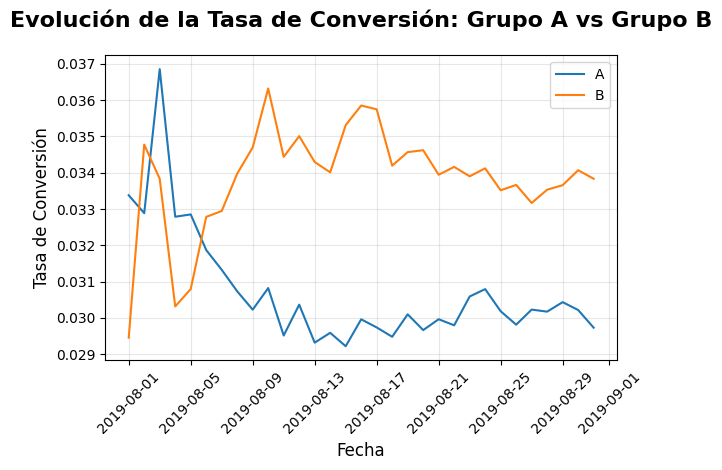

In [99]:
cumulativedata['conversion'] = cumulativedata['orders'] / cumulativedata['visitors']
cumulativedataA = cumulativedata[cumulativedata['group']=='A']
cumulativedataB = cumulativedata[cumulativedata['group']=='B']
plt.plot(cumulativedataA['date'], cumulativedataA['conversion'],
label='A')
plt.plot(cumulativedataB['date'], cumulativedataB['conversion'],
label='B')
plt.title('Evolución de la Tasa de Conversión: Grupo A vs Grupo B', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa de Conversión', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**-** Los grupos fluctuaron alrededor del mismo valor pero luego la tasa de conversión del grupo A disminuyó antes de estabilizarse, mientras que la tasa de conversión del grupo B aumentó  pero luego también se estabilizó. 

### 4.1. Representación gráfica de las tasas de conversión diarias de ambos grupos.

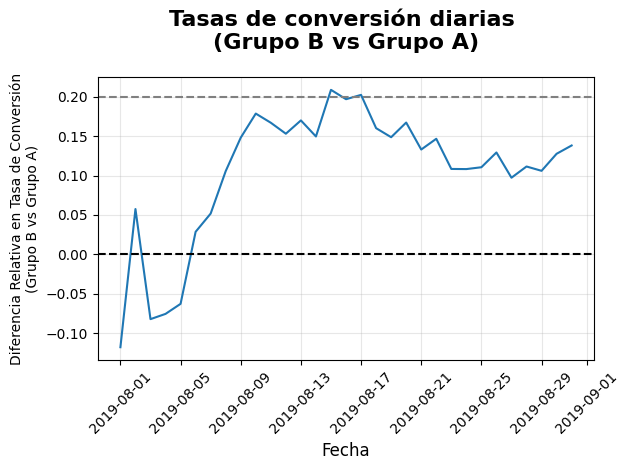

In [112]:
mergeCumulativeConversions = cumulativedataA[['date', 'conversion']].merge(
    cumulativedataB[['date', 'conversion']],
    left_on= 'date',
    right_on= 'date',
    how= 'left',
    suffixes= ['A','B']
)
plt.plot(
    mergeCumulativeConversions['date'],
    mergeCumulativeConversions['conversionB']
    / mergeCumulativeConversions['conversionA']
    -1
)
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.2, color='grey', linestyle='--')
plt.title('Tasas de conversión diarias \n(Grupo B vs Grupo A)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Diferencia Relativa en Tasa de Conversión\n(Grupo B vs Grupo A)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**-** El Grupo B va a la delantera y se mantiene mucho más alto y estable que el Grupo A. Sin embargo, primero debemos revisar las anomalías, ya que podrían alterar la interpretación de los resultados y afectar la comparación entre ambos grupos, permitiendo confirmar con mayor precisión cuál de los dos realmente lidera.

### 5. Gráfico de dispersión del número de pedidos por usuario. 

In [101]:
transactionByVisitor = (
    df_orders.groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
transactionByVisitor.columns = ['visitorid', 'transactions']
transactionByVisitor.sort_values(by='transactions', ascending= False).head(10)


,visitorid,transactions
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


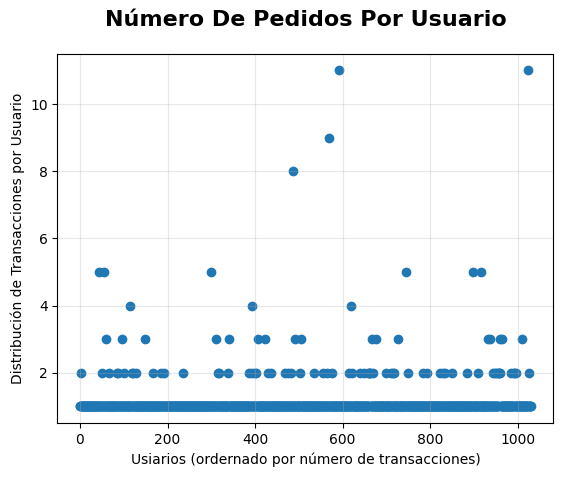

In [102]:
x_values= pd.Series(range(0, len(transactionByVisitor)))
plt.scatter(x_values, transactionByVisitor['transactions'])
plt.title('Número De Pedidos Por Usuario', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Usiarios (ordernado por número de transacciones)')
plt.ylabel('Distribución de Transacciones por Usuario')
plt.grid(True, alpha=0.3)
plt.show()

**-** La mayoría de unisarios realizaron 2 pedidos. Mientras que otros realizaron de 3 a 5 pedidos.

**-** Muy pocos usuarios realizan entre 8 y 11 pedidos. 

### 6. Percentiles 95 y 99 del número de pedidos por usuario.

In [103]:
np.percentile(transactionByVisitor['transactions'],[95,99])

array([2., 4.])

**-** No más del 5% de los usuarios realizaron más de dos pedidos y no más del 1% de los usuarios realizaron más de 4.

### 7. Gráfico de dispersión de los precios de los pedidos.

In [104]:
df_orders.sort_values(by='revenue', ascending=False).head(10)

,transactionid,visitorid,date,revenue,group
425,590470918,1920142716,2019-08-19,19920.4,B
1196,3936777065,2108080724,2019-08-15,3120.1,B
858,192721366,1316129916,2019-08-27,1450.2,A
1136,666610489,1307669133,2019-08-13,1425.8,A
744,3668308183,888512513,2019-08-27,1335.6,B
662,1811671147,4266935830,2019-08-29,1220.2,A
682,1216533772,4266935830,2019-08-29,1220.2,B
743,3603576309,4133034833,2019-08-09,1050.0,A
1103,1348774318,1164614297,2019-08-12,1025.8,A
1099,316924019,148427295,2019-08-12,1015.9,A


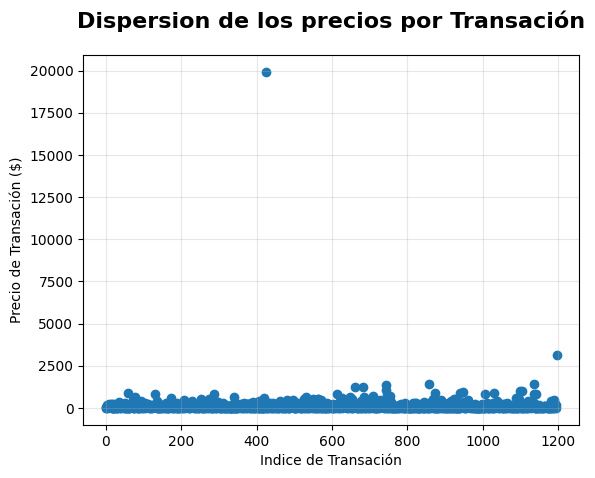

In [105]:
x_values = pd.Series(range(0, len(df_orders['revenue'])))
plt.scatter(x_values, df_orders['revenue'])
plt.title('Dispersion de los precios por Transación', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Indice de Transación')
plt.ylabel('Precio de Transación ($)')
plt.grid(True, alpha=0.3)
plt.show()

**-** La gran mayoría de transacciones están en el rango bajo de precios de 0 a 2500.

**-**  Existe una transacción por casi $20,000.
    

### 8. Percentiles 95 y 99 de los precios de los pedidos.

In [106]:
print('Percentiles 90/95/99:', np.percentile(df_orders['revenue'], [95, 99]))

Percentiles 90/95/99: [435.54  900.904]


**-**  No más del 5% de los usuarios realizó pedidos por más de $435.54. 

**-** No más del 1% realizaron pedidos más caros que $900.904

### 9. Significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto.

In [107]:
ordersByUsersA = (
    df_orders[df_orders['group'] == 'A']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
ordersByUsersB = (
    df_orders[df_orders['group'] == 'B']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)

sampleA = pd.concat([
    ordersByUsersA['transactionid'],
    pd.Series(
        0,
        index=np.arange(
            df_visits[df_visits['group'] == 'A']['visits'].sum()
            - len(ordersByUsersA['transactionid'])
        ),
        name='transactionid',
    )
])

sampleB = pd.concat([
    ordersByUsersB['transactionid'],
    pd.Series(
        0,
        index=np.arange(
            df_visits[df_visits['group'] == 'B']['visits'].sum()
            - len(ordersByUsersB['transactionid'])
        ),
        name='transactionid',
    )
])

print('{0:.5f}'.format(stats.mannwhitneyu(sampleA, sampleB)[1]))
print('{0:.3f}'.format(sampleB.mean() / sampleA.mean() - 1))

0.01679
0.138


**-** El valor p es inferior a 0,05 por lo que rechazamos la hipótesis nula ya que no hay una diferencia estadísticamente significativa en la conversión entre los grupos. El análisis de datos sin procesar mostró diferencias estadísticamente significativas en las tasas de conversión entre los grupos. La ganancia de conversión relativa del grupo B en comparación con el grupo A es del 13.8%. 

### 10. Significancia estadística de la diferencia en el tamaño promedio de pedido.

In [108]:
print('{0:.3f}'.format(stats.mannwhitneyu(df_orders[df_orders['group']=='A']['revenue'],
df_orders[df_orders['group']=='B']['revenue'])[1]))
print('{0:.3f}'.format(df_orders[df_orders['group']=='B']['revenue']
    .mean()/df_orders[df_orders['group']=='A']['revenue'].mean()-1))

0.692
0.252


**-** El valor p es superior a 0.05 por lo que no existen diferencias estadísticamente significativas entre los tamaños de pedido promedio de los grupos. Además, la diferencia relativa es del 25,2%.

### 11. Significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados.

In [109]:
# Identificar usuarios con más de 2 pedidos (outliers)
users_with_many_orders = transactionByVisitor[transactionByVisitor['transactions'] > 2]['visitorid']

# Identificar pedidos con precios superiores al percentil 99
high_value_orders = df_orders[df_orders['revenue'] > 900.904]['transactionid']

print(f"Usuarios con más de 2 pedidos: {len(users_with_many_orders)}")
print(f"Pedidos con valor > $900.904: {len(high_value_orders)}")

Usuarios con más de 2 pedidos: 30
Pedidos con valor > $900.904: 12


### 12. Significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados

In [110]:
print("=== CREANDO DATASETS FILTRADOS ===")

# Filtrar df_orders eliminando outliers de precio y usuarios con muchos pedidos
df_orders_filtered = df_orders[
    (df_orders['revenue'] <= 900.904) & 
    (~df_orders['visitorid'].isin(users_with_many_orders))
]

print(f"Órdenes originales: {len(df_orders)}")
print(f"Órdenes filtradas: {len(df_orders_filtered)}")
print(f"Órdenes eliminadas: {len(df_orders) - len(df_orders_filtered)}")

# Ahora vamos a repetir el análisis de significancia estadística con datos filtrados
print("\n=== ANÁLISIS DE CONVERSIÓN CON DATOS FILTRADOS ===")

# Crear muestras filtradas para análisis de conversión
ordersByUsersA_filtered = (
    df_orders_filtered[df_orders_filtered['group'] == 'A']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)

ordersByUsersB_filtered = (
    df_orders_filtered[df_orders_filtered['group'] == 'B']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)

sampleA_filtered = pd.concat([
    ordersByUsersA_filtered['transactionid'],
    pd.Series(
        0,
        index=np.arange(
            df_visits[df_visits['group'] == 'A']['visits'].sum()
            - len(ordersByUsersA_filtered['transactionid'])
        ),
        name='transactionid',
    )
])

sampleB_filtered = pd.concat([
    ordersByUsersB_filtered['transactionid'],
    pd.Series(
        0,
        index=np.arange(
            df_visits[df_visits['group'] == 'B']['visits'].sum()
            - len(ordersByUsersB_filtered['transactionid'])
        ),
        name='transactionid',
    )
])

# Prueba de significancia estadística con datos filtrados
p_value_filtered = stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]
conversion_gain_filtered = sampleB_filtered.mean() / sampleA_filtered.mean() - 1

print(f"P-valor (datos filtrados): {p_value_filtered:.5f}")
print(f"Ganancia de conversión (datos filtrados): {conversion_gain_filtered:.3f} ({conversion_gain_filtered*100:.1f}%)")

=== CREANDO DATASETS FILTRADOS ===
Órdenes originales: 1197
Órdenes filtradas: 1053
Órdenes eliminadas: 144

=== ANÁLISIS DE CONVERSIÓN CON DATOS FILTRADOS ===
P-valor (datos filtrados): 0.00845
Ganancia de conversión (datos filtrados): 0.178 (17.8%)


### 13. Toma una decisión basada en los resultados de la prueba

In [111]:
print("=== RESUMEN COMPLETO DE RESULTADOS ===")
print("\n📊 ANÁLISIS DE CONVERSIÓN:")
print("• Datos sin filtrar:")
print(f"  - P-valor: 0.01679 (< 0.05) → Estadísticamente significativo")
print(f"  - Ganancia de conversión: 13.8%")
print("• Datos filtrados:")
print(f"  - P-valor: 0.00845 (< 0.05) → Estadísticamente significativo") 
print(f"  - Ganancia de conversión: 17.8%")

print("\n💰 ANÁLISIS DE TAMAÑO PROMEDIO DE PEDIDO:")
print("• Datos sin filtrar:")
print(f"  - P-valor: 0.692 (> 0.05) → NO estadísticamente significativo")
print(f"  - Diferencia: 25.2%")

print("\n🔍 OUTLIERS IDENTIFICADOS:")
print(f"• {len(users_with_many_orders)} usuarios con más de 2 pedidos")
print(f"• {len(high_value_orders)} pedidos con valor > $900.904")
print(f"• Total de órdenes eliminadas: {len(df_orders) - len(df_orders_filtered)} de {len(df_orders)} ({((len(df_orders) - len(df_orders_filtered))/len(df_orders)*100):.1f}%)")

=== RESUMEN COMPLETO DE RESULTADOS ===

📊 ANÁLISIS DE CONVERSIÓN:
• Datos sin filtrar:
  - P-valor: 0.01679 (< 0.05) → Estadísticamente significativo
  - Ganancia de conversión: 13.8%
• Datos filtrados:
  - P-valor: 0.00845 (< 0.05) → Estadísticamente significativo
  - Ganancia de conversión: 17.8%

💰 ANÁLISIS DE TAMAÑO PROMEDIO DE PEDIDO:
• Datos sin filtrar:
  - P-valor: 0.692 (> 0.05) → NO estadísticamente significativo
  - Diferencia: 25.2%

🔍 OUTLIERS IDENTIFICADOS:
• 30 usuarios con más de 2 pedidos
• 12 pedidos con valor > $900.904
• Total de órdenes eliminadas: 144 de 1197 (12.0%)


# 🧾  Resumen ejecutivo

**Contexto & objetivo:** El presente proyecto tiene como objetivo analizar el desempeño de una gran tienda online. En colaboración con el departamento de marketing, se ha recopilado un conjunto de hipótesis orientadas a incrementar los ingresos. Como parte del proceso, es fundamental priorizar dichas hipótesis para identificar cuáles tienen mayor potencial de impacto antes de su implementación mediante pruebas A/B.
El análisis se centra, en primer lugar, en la priorización de hipótesis utilizando los frameworks ICE (Impact, Confidence, Ease) y RICE (Reach, Impact, Confidence, Effort), con el fin de comparar cómo varía la clasificación de prioridades al aplicar cada metodología.
En segundo lugar, se lleva a cabo el análisis del test A/B, evaluando los siguientes indicadores clave:

- Ingreso acumulado por grupo.
- Tamaño promedio de pedido acumulado por grupo.
- Diferencia relativa en el tamaño promedio de pedido entre el grupo B y el grupo A.
- Tasa de conversión diaria de cada grupo (definida como la relación entre el número de pedidos y el número de visitas).
- Distribución del número de pedidos por usuario.
- Percentiles 95 y 99 del número de pedidos por usuario.
- Distribución de los precios de los pedidos.
- Percentiles 95 y 99 de los precios de los pedidos
Adicionalmente, se evalúa la significancia estadística de las diferencias entre los grupos en términos de:
-Tasa de conversión (utilizando datos en bruto y datos filtrados).
-Tamaño promedio de pedido (utilizando datos en bruto y datos filtrados).
Finalmente, con base en los resultados obtenidos, se formula una recomendación sobre la continuidad, modificación o finalización del test A/B.

**-** Cobertura de datos:
Se utilizaron tres conjuntos de datos principales, organizados en los siguientes dataframes:
- Hipótesis
- Órdenes
- Visitas

**-** Metodología (alto nivel):
- Limpieza de datos:
Se realizó la estandarización de formatos, la normalización de los nombres de las columnas y la corrección de los tipos de datos. Este proceso permitió garantizar la calidad, consistencia y confiabilidad de la información para el análisis.
- Transformación de datos:
Se emplearon funciones como concat para la integración de datasets y groupby para la agregación de la información por categorías. Se aplicaron métricas como suma, promedio y conteo para generar variables analíticas relevantes.
- Visualización de datos:
Se utilizaron gráficos de dispersión (scatter plots) para analizar la distribución de variables y detectar posibles anomalías o valores atípicos. Adicionalmente, se emplearon otras visualizaciones para facilitar la interpretación de patrones y tendencias en los datos.

**Hallazgos iniciales:**  
Conversión (Grupo B vs Grupo A):
- Con datos sin filtrar: Grupo B tuvo 13.8% mejor conversión
- Con datos filtrados: Grupo B tuvo 17,8% mejor conversión
- Ambos resultados fueron estadísticamente significativos (p < 0.05)

**Recomendaciones:**  
- Conversión (Grupo B vs Grupo A):
  Con datos sin filtrar: Grupo B tuvo 13.8% mejor conversión
  Con datos filtrados: Grupo B tuvo 17,8% mejor conversión
  Ambos resultados fueron estadísticamente significativos (p < 0.05)
- ¿Por qué el Grupo B tuvo un mejor rendimiento?
  Tasa de conversión más estable: En tus gráficos observaste que el Grupo B mantuvo una tasa de conversión más alta y estable
  Menos volatilidad: El Grupo A mostró más fluctuaciones y una tendencia a la baja en conversión
  Mejora consistente: El Grupo B mostró una mejora sostenida a lo largo del tiempo
- Posibles razones para esta diferencia:
  El cambio implementado en el Grupo B (la nueva versión) fue más efectivo
  Los usuarios del Grupo B respondieron mejor a las modificaciones
- La experiencia de usuario mejorada en el Grupo B generó más conversiones

**Conclusion:**
- Parar la prueba, considerar  a uno de los grupos como líder en este caso fue el grupo B.